In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [26]:
def survive_exactly(death_chance, t):
    ''' Probability of surviving exactly to time step p given a constant 
        death_chance independent at each step.'''
    if not isinstance(t, int):
        raise TypeError
    else:
        return (1-death_chance)**(t-1)*death_chance if t > 0 else 0

def p_lessequal(n_periods, death_chance):
    
    return pd.Series([sum(survive_exactly(death_chance, t) for t in range(1,t)) for t in range(1, n_periods)])

In [43]:
start_pop = 12
birth_rate = 1
death_chance = 0.1
n_periods = 25

In [44]:
prob = p_lessequal(n_periods, death_chance)
prob

0     0.000000
1     0.100000
2     0.190000
3     0.271000
4     0.343900
5     0.409510
6     0.468559
7     0.521703
8     0.569533
9     0.612580
10    0.651322
11    0.686189
12    0.717570
13    0.745813
14    0.771232
15    0.794109
16    0.814698
17    0.833228
18    0.849905
19    0.864915
20    0.878423
21    0.890581
22    0.901523
23    0.911371
dtype: float64

In [45]:
pop = start_pop + prob*(pop_equilib(birth_rate, death_chance) - start_pop)
pop

0     12.000000
1     11.800000
2     11.620000
3     11.458000
4     11.312200
5     11.180980
6     11.062882
7     10.956594
8     10.860934
9     10.774841
10    10.697357
11    10.627621
12    10.564859
13    10.508373
14    10.457536
15    10.411782
16    10.370604
17    10.333544
18    10.300189
19    10.270170
20    10.243153
21    10.218838
22    10.196954
23    10.177259
dtype: float64

In [46]:
def recursive_pop(n_periods, death_chance, birth_rate, pop):
    ''' Recursive function for popualtion growth with contstant birth rate and
        independent death chance'''

    p_function = [pop] #pop_0 is first item, the function returns
    for t in range(0,n_periods): #pop_t+1 for any t.
        pop = pop*(1-death_chance)+birth_rate
        p_function.append(pop)
    return p_function

def pop_equilib(birth_rate, death_chance):
    ''' Calculate the population equilibrium for population with constant birth rate
        and independent death chance'''

    return birth_rate/death_chance

In [47]:
recursive_pop(n_periods, death_chance, birth_rate, pop)

[0     12.000000
 1     11.800000
 2     11.620000
 3     11.458000
 4     11.312200
 5     11.180980
 6     11.062882
 7     10.956594
 8     10.860934
 9     10.774841
 10    10.697357
 11    10.627621
 12    10.564859
 13    10.508373
 14    10.457536
 15    10.411782
 16    10.370604
 17    10.333544
 18    10.300189
 19    10.270170
 20    10.243153
 21    10.218838
 22    10.196954
 23    10.177259
 dtype: float64, 0     11.800000
 1     11.620000
 2     11.458000
 3     11.312200
 4     11.180980
 5     11.062882
 6     10.956594
 7     10.860934
 8     10.774841
 9     10.697357
 10    10.627621
 11    10.564859
 12    10.508373
 13    10.457536
 14    10.411782
 15    10.370604
 16    10.333544
 17    10.300189
 18    10.270170
 19    10.243153
 20    10.218838
 21    10.196954
 22    10.177259
 23    10.159533
 dtype: float64, 0     11.620000
 1     11.458000
 2     11.312200
 3     11.180980
 4     11.062882
 5     10.956594
 6     10.860934
 7     10.774841
 8     10.697357

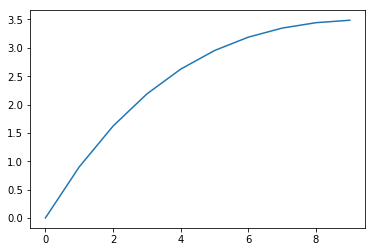

In [64]:
plt.plot(pop)